# Exploratory Data Analysis
DSAI 305 | NIH ChestX-ray14 | Multi-Class Lung Disease Classification (12 classes)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
DATA_SPLITS  = PROJECT_ROOT / 'data' / 'splits'
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
EDA_OUTPUT   = PROJECT_ROOT / 'outputs' / 'eda'
EDA_OUTPUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print(f'EDA output dir: {EDA_OUTPUT}')

EDA output dir: C:\RIE\outputs\eda


## 1 — Load Splits


In [13]:
df_train = pd.read_csv(DATA_SPLITS / 'train.csv')
df_val   = pd.read_csv(DATA_SPLITS / 'val.csv')
df_test  = pd.read_csv(DATA_SPLITS / 'test.csv')

# Normalize column names
for _df in [df_train, df_val, df_test]:
    if 'patient_id' not in _df.columns and 'pid_str' in _df.columns:
        _df['patient_id'] = _df['pid_str']

df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

try:
    df_meta = pd.read_csv(DATA_RAW / 'Data_Entry_2017.csv')
    print(f'Loaded NIH metadata: {len(df_meta):,} rows')
except FileNotFoundError:
    df_meta = None
    print('NIH metadata not found.')

print(f'Total dataset: {len(df_all):,} images')
print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


NIH metadata not found.
Total dataset: 17,172 images
Train: 11,943 | Val: 2,611 | Test: 2,618


## 2 — Dataset Overview


In [14]:
splits_info = [
    ('Train', df_train),
    ('Val',   df_val),
    ('Test',  df_test),
]


## 3 — Class Imbalance Analysis

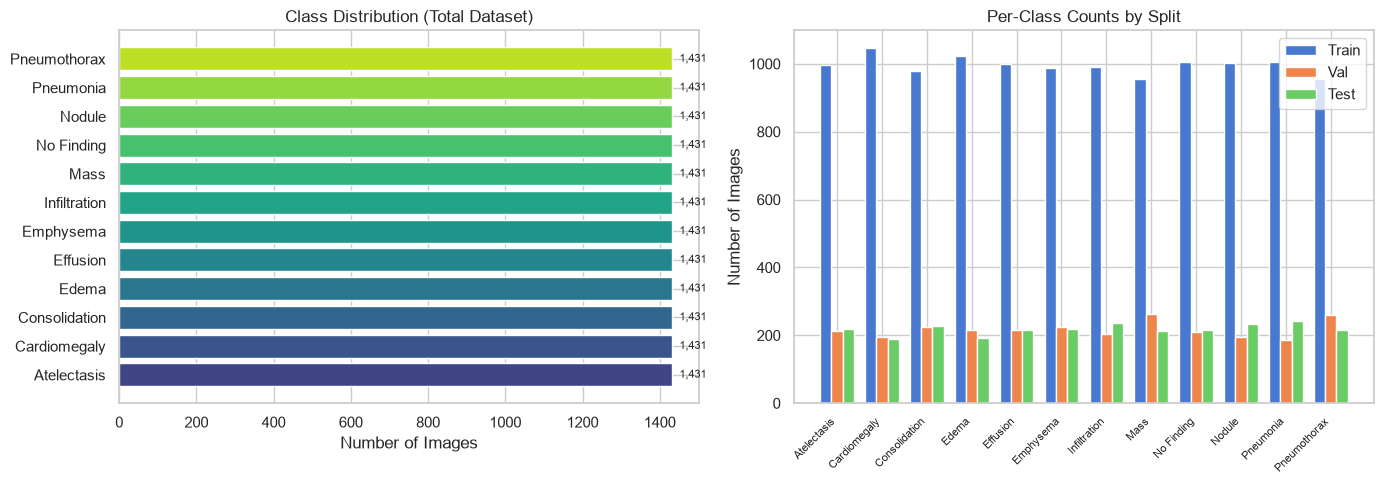

In [15]:
CLASS_NAMES = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
               'Effusion', 'Emphysema', 'Infiltration', 'Mass', 'No Finding',
               'Nodule', 'Pneumonia', 'Pneumothorax']

label_map = {
    0: 'Atelectasis',
    1: 'Cardiomegaly',
    2: 'Consolidation',
    3: 'Edema',
    4: 'Effusion',
    5: 'Emphysema',
    6: 'Infiltration',
    7: 'Mass',
    8: 'No Finding',
    9: 'Nodule',
    10: 'Pneumonia',
    11: 'Pneumothorax',
}
inv_label_map = {v: k for k, v in label_map.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall class distribution
ax = axes[0]
cls_counts = []
for name in CLASS_NAMES:
    cnt = int((df_all['label'] == inv_label_map[name]).sum())
    cls_counts.append(cnt)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(CLASS_NAMES)))
bars = ax.barh(CLASS_NAMES, cls_counts, color=colors)
for bar, v in zip(bars, cls_counts):
    ax.text(v + 20, bar.get_y() + bar.get_height()/2, f'{v:,}',
            va='center', fontsize=8)
ax.set_title('Class Distribution (Total Dataset)')
ax.set_xlabel('Number of Images')

# Per-split class distribution
ax = axes[1]
split_names = ['Train', 'Val', 'Test']
dfs = [df_train, df_val, df_test]
x = np.arange(len(CLASS_NAMES))
w = 0.25
for i, (sn, df) in enumerate(zip(split_names, dfs)):
    counts = [int((df['label'] == inv_label_map[name]).sum()) for name in CLASS_NAMES]
    ax.bar(x + (i - 1) * w, counts, w, label=sn)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_title('Per-Class Counts by Split')
ax.set_ylabel('Number of Images')
ax.legend()

plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 — Pathology Distribution (Full NIH Dataset)

In [16]:
if df_meta is not None:
    all_labels = df_meta['Finding Labels'].str.split('|').explode()
    label_counts = all_labels.value_counts()

    fig, ax = plt.subplots(figsize=(12, 7))
    label_counts.plot(kind='barh', ax=ax,
                      color=sns.color_palette('viridis', len(label_counts)))
    ax.set_title('Distribution of All Finding Labels (Full Dataset)')
    ax.set_xlabel('Number of Occurrences')
    for i, v in enumerate(label_counts.values):
        ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'pathology_distribution.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('NIH metadata not available — skipping pathology chart.')

NIH metadata not available — skipping pathology chart.


## 5 — Patient-Level Analysis

In [17]:
if df_meta is not None:
    images_per_patient = df_meta.groupby('Patient ID').size()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    clipped = images_per_patient.clip(upper=20)
    ax.hist(clipped, bins=min(20, clipped.nunique()), color='steelblue', edgecolor='white')
    ax.set_title('Images per Patient (clipped at 20)')
    ax.set_xlabel('Number of Images')
    ax.set_ylabel('Number of Patients')

    ax = axes[1]
    all_labels = df_meta['Finding Labels'].str.split('|').explode()
    label_counts = all_labels.value_counts().head(15)
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(label_counts)))
    bars = ax.barh(label_counts.index, label_counts.values, color=colors)
    for bar, v in zip(bars, label_counts.values):
        ax.text(v + 100, bar.get_y() + bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8)
    ax.set_title('Most Common Pathologies (Full NIH Dataset)')
    ax.set_xlabel('Number of Occurrences')

    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'patient_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    avg_img = images_per_patient.mean()
    print(f'Total patients : {images_per_patient.sum():,}')
    print(f'Unique patients: {len(images_per_patient):,}')
    print(f'Avg images/patient: {avg_img:.2f}')

## 6 — Demographic Analysis

In [18]:
if df_meta is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Age distribution
    ax = axes[0]
    valid_ages = df_meta['Patient Age'][
        (df_meta['Patient Age'] > 0) & (df_meta['Patient Age'] < 120)
    ]
    ax.hist(valid_ages, bins=30, color='steelblue', edgecolor='white')
    ax.set_title('Patient Age Distribution')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')

    # Gender distribution
    ax = axes[1]
    gender_counts = df_meta['Patient Gender'].value_counts()
    ax.pie(gender_counts.values,
           labels=gender_counts.index,
           autopct='%1.1f%%',
           colors=['#42A5F5','#EF5350'],
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title('Gender Distribution')

    # Labels per image distribution
    ax = axes[2]
    n_labels = df_meta['Finding Labels'].str.split('|').apply(len)
    n_labels_counts = n_labels.value_counts().sort_index()
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(n_labels_counts)))
    bars = ax.bar(n_labels_counts.index.astype(str), n_labels_counts.values,
                  color=colors, edgecolor='white')
    for bar, v in zip(bars, n_labels_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                str(v), ha='center', fontsize=8)
    ax.set_title('Labels per Image')
    ax.set_xlabel('Number of Labels')
    ax.set_ylabel('Number of Images')

    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'demographics.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 7 — View Position Analysis

In [19]:
if df_meta is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    vp_counts = df_meta['View Position'].value_counts()
    colors = sns.color_palette('Set2', len(vp_counts))
    bars = ax.bar(vp_counts.index, vp_counts.values, color=colors, edgecolor='white')
    for bar, v in zip(bars, vp_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'{v:,}', ha='center', fontsize=10)
    ax.set_title('View Position Distribution')
    ax.set_ylabel('Count')

    ax = axes[1]
    # View position by class (top classes)
    top_classes = ['Cardiomegaly', 'Emphysema', 'Hernia', 'Mass', 'Nodule']
    vp_by_class = df_meta[df_meta['Finding Labels'].isin(top_classes)]
    vp_class_counts = vp_by_class.groupby(['View Position', 'Finding Labels']).size().unstack(fill_value=0)
    vp_class_counts.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
    ax.set_title('View Position by Pathology')
    ax.set_ylabel('Count')
    ax.legend(title='Pathology', fontsize=8)
    ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'view_position.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 8 — Sample Image Visualization

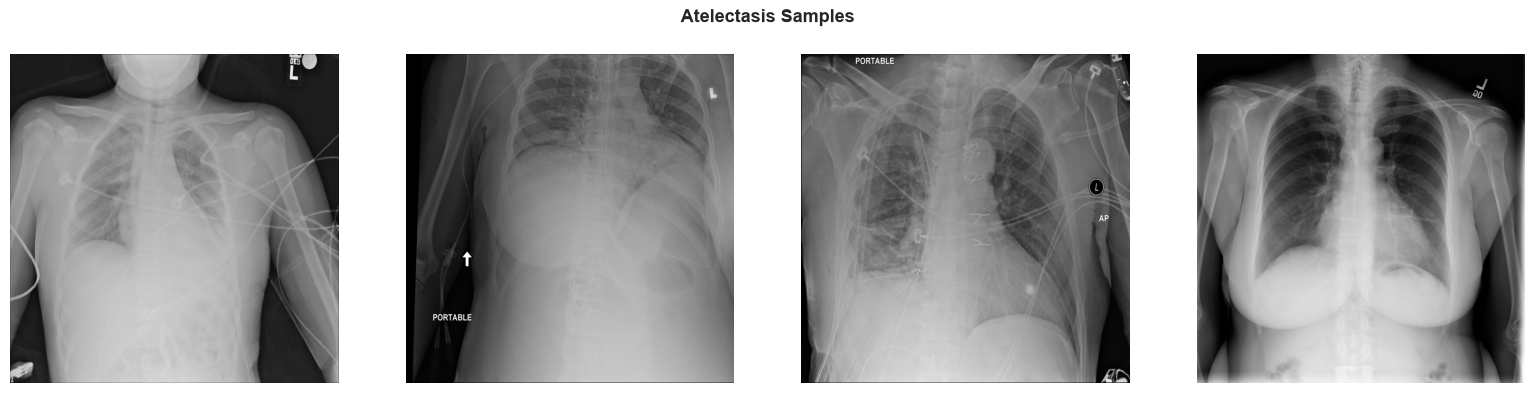

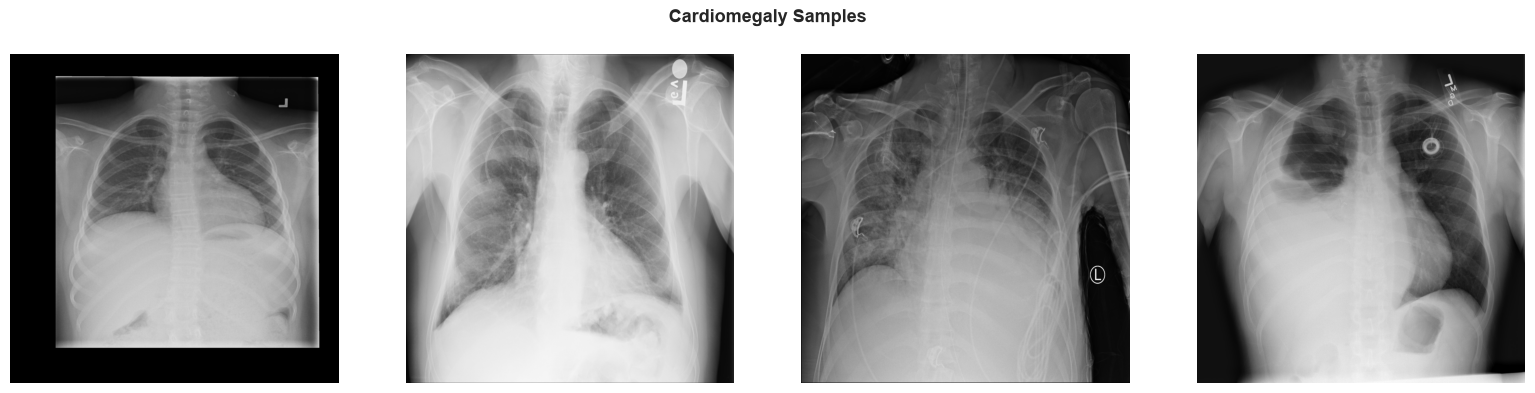

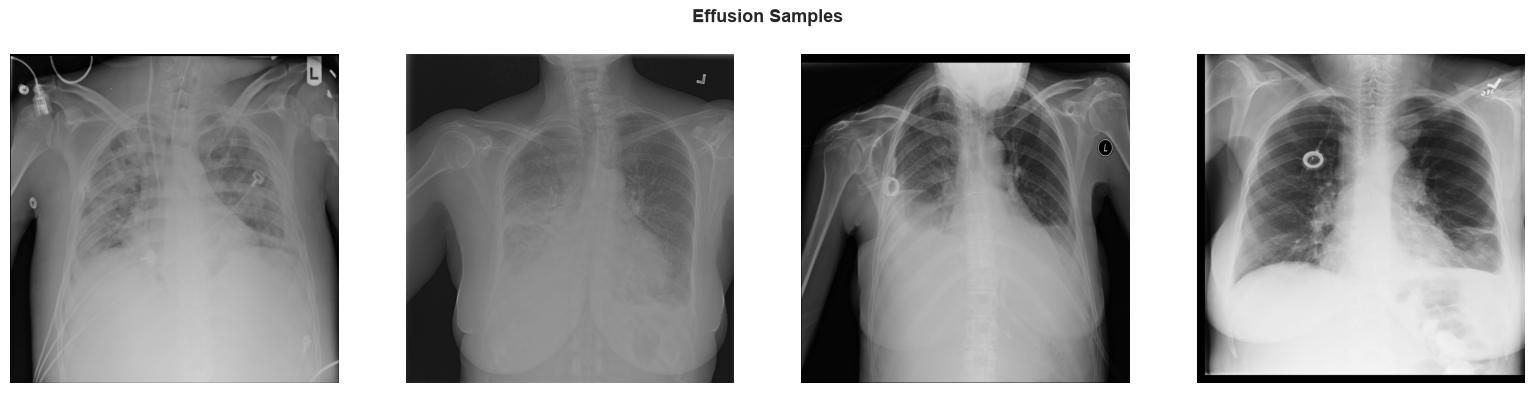

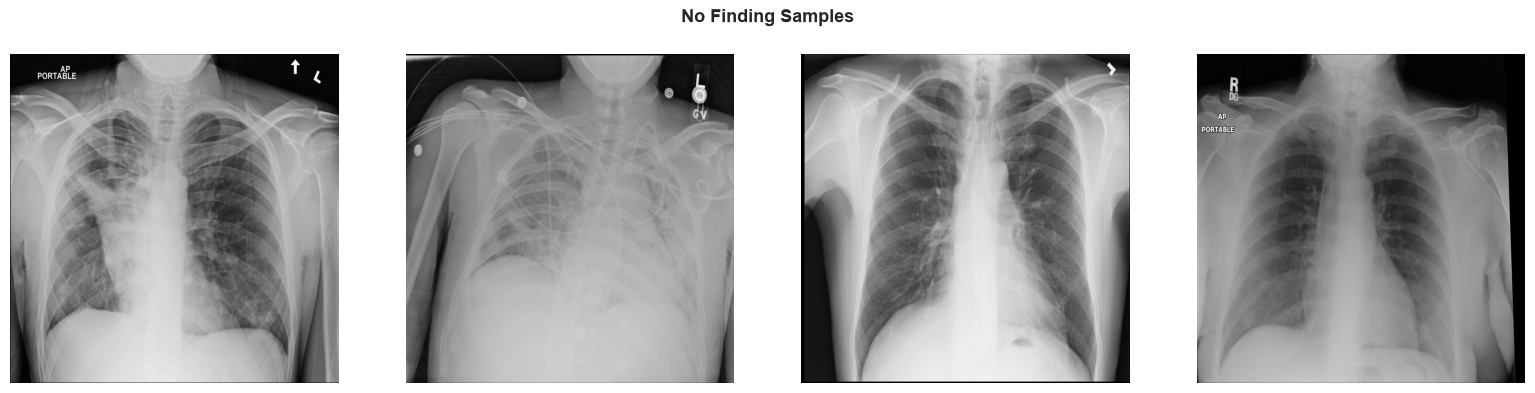

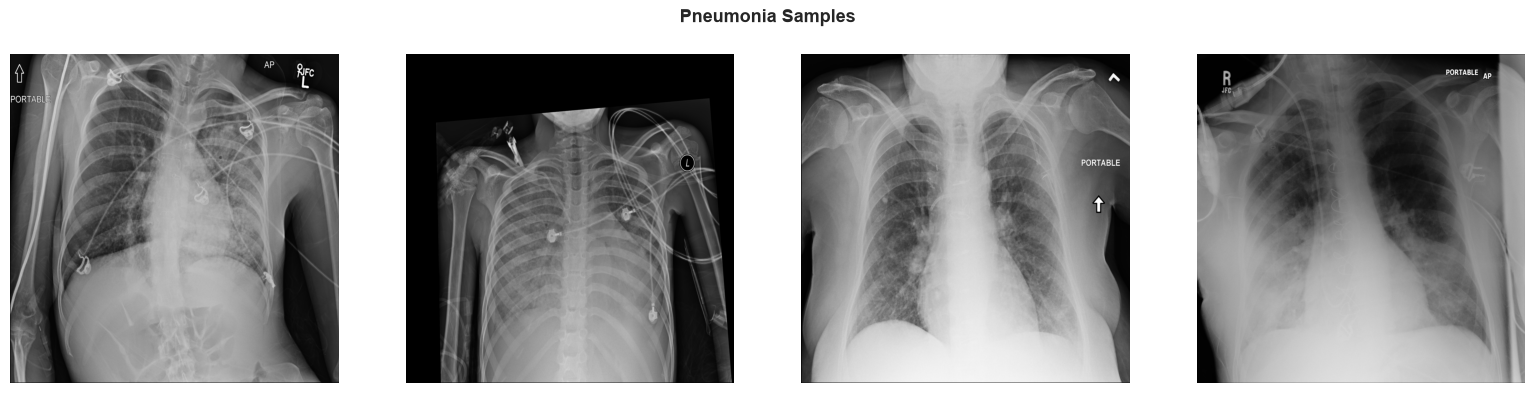

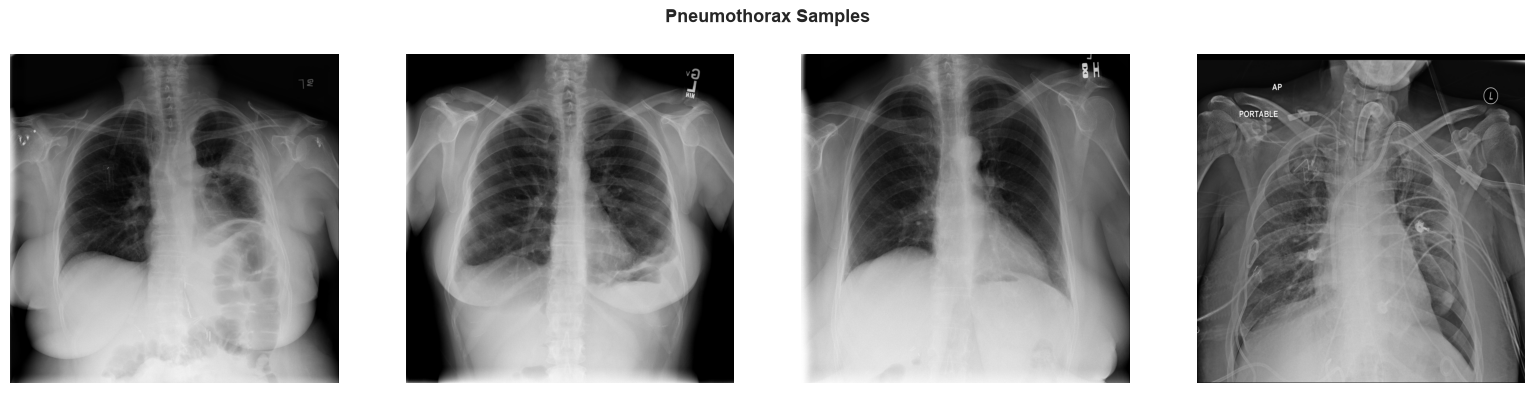

Sample images saved.


In [20]:
def show_samples_by_class(df, class_name, class_label, n=4):
    subset  = df[df['label'] == class_label]
    n_available = min(n, len(subset))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    fig.suptitle(f'{class_name} Samples', fontsize=13, fontweight='bold')
    if n_available == 0:
        for ax in axes:
            ax.text(0.5, 0.5, 'No samples\navailable',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.axis('off')
        plt.tight_layout()
        return fig
    samples = subset.sample(n=n_available, random_state=42)
    for ax, (_, row) in zip(axes, samples.iterrows()):
        p = str(row.get('image_path', ''))
        if p and Path(p).exists():
            img = Image.open(p).convert('RGB')
            ax.imshow(img, cmap='gray')
        else:
            ax.text(0.5, 0.5, f'Image not found:\n{p}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=8, color='red')
        ax.axis('off')
    for ax in axes[n_available:]:
        ax.axis('off')
    plt.tight_layout()
    return fig

sample_classes = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'No Finding', 'Pneumonia', 'Pneumothorax']
label_to_name = {0:'Atelectasis',1:'Cardiomegaly',2:'Consolidation',3:'Edema',4:'Effusion',
                 5:'Emphysema',6:'Infiltration',7:'Mass',8:'No Finding',9:'Nodule',10:'Pneumonia',11:'Pneumothorax'}
name_to_label = {v:k for k,v in label_to_name.items()}

try:
    for cls_name in sample_classes:
        fig = show_samples_by_class(df_val, cls_name, name_to_label[cls_name])
        fname = cls_name.lower().replace(' ', '_')
        fig.savefig(EDA_OUTPUT / f'sample_{fname}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    print('Sample images saved.')
except Exception as e:
    print(f'Could not display images: {e}')

## 9 — Training Set Source & Weight Analysis

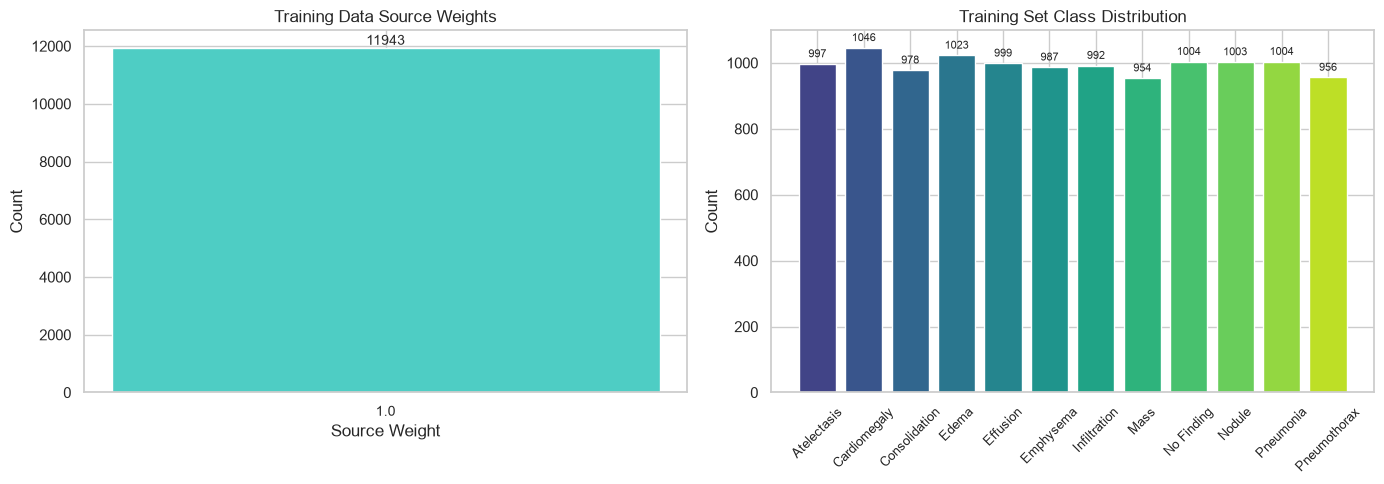

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data source breakdown
ax = axes[0]
if 'source_weight' in df_train.columns:
    sw_counts = df_train['source_weight'].value_counts().sort_index()
    colors = ['#4ECDC4', '#FFE66D'][:len(sw_counts)]
    bars = ax.bar(sw_counts.index.astype(str), sw_counts.values,
                  color=colors, edgecolor='white')
    for bar, v in zip(bars, sw_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                str(v), ha='center', fontsize=10)
    ax.set_xlabel('Source Weight')
else:
    ax.text(0.5, 0.5, 'No source_weight data',
            ha='center', va='center', transform=ax.transAxes)
ax.set_title('Training Data Source Weights')
ax.set_ylabel('Count')
ax.tick_params(axis='x', labelsize=10)

# Class distribution in training set
ax = axes[1]
int_to_name = {0:'Atelectasis',1:'Cardiomegaly',2:'Consolidation',3:'Edema',4:'Effusion',
               5:'Emphysema',6:'Infiltration',7:'Mass',8:'No Finding',9:'Nodule',10:'Pneumonia',11:'Pneumothorax'}
cls_counts = df_train['label'].value_counts().sort_index()
cls_names = [int_to_name.get(int(i), f'class_{i}') for i in cls_counts.index]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cls_names)))
bars = ax.bar(cls_names, cls_counts.values, color=colors, edgecolor='white')
ax.set_title('Training Set Class Distribution')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45, labelsize=9)
for bar, v in zip(bars, cls_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'training_source_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 10 — Val Contamination Analysis

> **Note:** Val Contamination Analysis is obsolete. The new canonical splits generated by `scripts/rebuild_clean_splits.py` are strictly binary and 100% clean.

## 11 — EDA Summary

In [22]:
df_train = pd.read_csv(DATA_SPLITS / 'train.csv')
df_val   = pd.read_csv(DATA_SPLITS / 'val.csv')
df_test  = pd.read_csv(DATA_SPLITS / 'test.csv')

# Normalize column names
for _df in [df_train, df_val, df_test]:
    if 'patient_id' not in _df.columns and 'pid_str' in _df.columns:
        _df['patient_id'] = _df['pid_str']

df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'Total dataset: {len(df_all):,} images')
print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Total dataset: 17,172 images
Train: 11,943 | Val: 2,611 | Test: 2,618
